# Product Experimentation with Propensity Scores: Causal Inference for LLM-Based Features in Python

**Keywords:** product experimentation, causal inference, propensity score matching, inverse-probability weighting, LLM applications, generative AI

## What this notebook does

Measures the causal effect of an AI feature ("agent mode") that ships behind a user-controlled opt-in toggle, where the naive opted-in vs. non-opted-in comparison is contaminated by selection bias. Covers propensity score estimation, inverse-probability weighting (ATE and ATT), 1-nearest-neighbor matching, covariate balance via standardized mean differences, and bootstrap 95% confidence intervals.

## Dataset

A 50,000-user synthetic SaaS dataset where the ground-truth causal effect of opting into agent mode is **+8 percentage points** on task completion. The naive comparison inflates this to around +21 percentage points because heavy-engagement users opt in at 65% while light users opt in at 12%.

## Run

From the repo root:

```bash
python data/generate_data.py --seed 42 --n-users 50000 \
    --out data/synthetic_llm_logs.csv
jupyter notebook 02_propensity_opt_in/psm_demo.ipynb
```

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv("../data/synthetic_llm_logs.csv")
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

Loaded 50,000 rows, 16 columns


## Setting up the working example

Opt-in rates differ sharply by engagement tier. The naive comparison folds selection bias into the effect estimate.

In [2]:
print(df.groupby("engagement_tier").opt_in_agent_mode.mean().round(3))

naive_effect = (
    df[df.opt_in_agent_mode == 1].task_completed.mean()
    - df[df.opt_in_agent_mode == 0].task_completed.mean()
)
print(f"\nNaive opt-in effect: {naive_effect:+.4f}")

engagement_tier
heavy     0.647
light     0.120
medium    0.353
Name: opt_in_agent_mode, dtype: float64

Naive opt-in effect: +0.2106


## Step 1: Estimate the propensity score

Logistic regression predicting opt-in from engagement tier and query confidence. AUC confirms the model discriminates above chance.

In [3]:
X = pd.get_dummies(
    df[["engagement_tier", "query_confidence"]],
    drop_first=True
).astype(float)
y_treat = df.opt_in_agent_mode

ps_model = LogisticRegression(max_iter=1000).fit(X, y_treat)
df["propensity"] = ps_model.predict_proba(X)[:, 1]

print(df.groupby("engagement_tier").propensity.mean().round(3))
print(
    f"\nPropensity range (treated):  "
    f"{df[df.opt_in_agent_mode == 1].propensity.min():.3f} - "
    f"{df[df.opt_in_agent_mode == 1].propensity.max():.3f}"
)
print(
    f"Propensity range (control):  "
    f"{df[df.opt_in_agent_mode == 0].propensity.min():.3f} - "
    f"{df[df.opt_in_agent_mode == 0].propensity.max():.3f}"
)
print(f"Propensity model AUC: {roc_auc_score(y_treat, df.propensity):.3f}")

engagement_tier
heavy     0.646
light     0.120
medium    0.353
Name: propensity, dtype: float64

Propensity range (treated):  0.114 - 0.675
Propensity range (control):  0.114 - 0.673
Propensity model AUC: 0.744


### Propensity score overlap (positivity check)

Both groups should have overlapping propensity distributions. If treated users cluster near 1 and controls near 0, positivity fails and no amount of weighting can recover a causal effect.

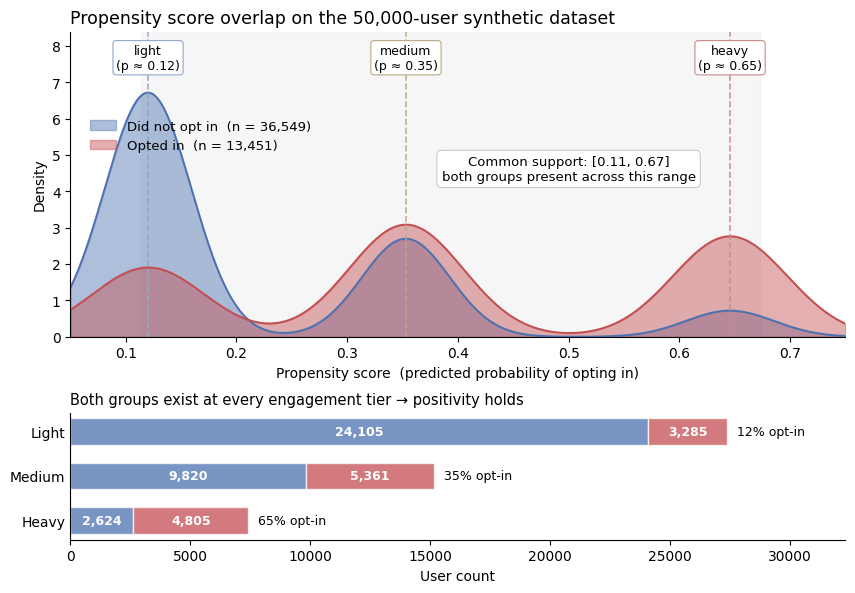

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

treated_ps = df[df.opt_in_agent_mode == 1].propensity.values
control_ps = df[df.opt_in_agent_mode == 0].propensity.values
common_lo = max(treated_ps.min(), control_ps.min())
common_hi = min(treated_ps.max(), control_ps.max())

tier_colors = {"light": "#8FA9C7", "medium": "#B8A886",
               "heavy": "#C88B8B"}
tier_order = ["light", "medium", "heavy"]

fig, (ax_top, ax_bot) = plt.subplots(
    nrows=2, figsize=(10.0, 6.6),
    gridspec_kw={"height_ratios": [2.4, 1.0], "hspace": 0.35}
)

# Top: smooth KDE curves
grid = np.linspace(0.05, 0.75, 400)
dens_c = gaussian_kde(control_ps, bw_method=0.25)(grid)
dens_t = gaussian_kde(treated_ps, bw_method=0.25)(grid)
ax_top.fill_between(grid, dens_c, alpha=0.45, color="#4C72B0",
                    label=f"Did not opt in  (n = {len(control_ps):,})")
ax_top.fill_between(grid, dens_t, alpha=0.45, color="#C44E52",
                    label=f"Opted in  (n = {len(treated_ps):,})")
ax_top.plot(grid, dens_c, color="#4C72B0", lw=1.4)
ax_top.plot(grid, dens_t, color="#C44E52", lw=1.4)
ax_top.axvspan(common_lo, common_hi, color="#EFEFEF", alpha=0.5, zorder=0)

y_top = max(dens_c.max(), dens_t.max()) * 1.25
ax_top.set_ylim(0, y_top)
for tier in tier_order:
    tier_df = df[df.engagement_tier == tier]
    center = tier_df.propensity.mean()
    ax_top.axvline(center, color=tier_colors[tier], lw=1.2, ls="--",
                   alpha=0.9)
    ax_top.text(center, y_top * 0.96, f"{tier}\n(p ≈ {center:.2f})",
                ha="center", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.25", fc="white",
                          ec=tier_colors[tier], lw=0.8))

ax_top.text(0.50, y_top * 0.55,
            f"Common support: [{common_lo:.2f}, {common_hi:.2f}]\n"
            "both groups present across this range",
            ha="center", va="center", fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.35", fc="white",
                      ec="#BBBBBB", lw=0.6))
ax_top.set_xlabel("Propensity score  (predicted probability of opting in)")
ax_top.set_ylabel("Density")
ax_top.set_title("Propensity score overlap on the 50,000-user synthetic dataset",
                 fontsize=12.5, loc="left")
ax_top.set_xlim(0.05, 0.75)
ax_top.legend(frameon=False, loc="upper left", fontsize=9.5,
              bbox_to_anchor=(0.01, 0.75))
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)

# Bottom: stacked count bars per tier
rows = [{"tier": t,
         "control": int(((df.engagement_tier == t) & (df.opt_in_agent_mode == 0)).sum()),
         "treated": int(((df.engagement_tier == t) & (df.opt_in_agent_mode == 1)).sum())}
        for t in tier_order]
y_pos = np.arange(len(tier_order))[::-1]
max_total = max(r["control"] + r["treated"] for r in rows)
for y, r in zip(y_pos, rows):
    ax_bot.barh(y, r["control"], color="#4C72B0", alpha=0.75,
                edgecolor="white", height=0.6)
    ax_bot.barh(y, r["treated"], left=r["control"], color="#C44E52",
                alpha=0.75, edgecolor="white", height=0.6)
    ax_bot.text(r["control"] / 2, y, f"{r['control']:,}",
                ha="center", va="center", fontsize=9,
                color="white", fontweight="bold")
    ax_bot.text(r["control"] + r["treated"] / 2, y, f"{r['treated']:,}",
                ha="center", va="center", fontsize=9,
                color="white", fontweight="bold")
    total = r["control"] + r["treated"]
    ax_bot.text(total + max_total * 0.015, y,
                f"{r['treated'] / total:.0%} opt-in",
                ha="left", va="center", fontsize=9)
ax_bot.set_yticks(y_pos)
ax_bot.set_yticklabels([r["tier"].capitalize() for r in rows])
ax_bot.set_xlim(0, max_total * 1.18)
ax_bot.set_xlabel("User count")
ax_bot.set_title("Both groups exist at every engagement tier → positivity holds",
                 fontsize=10.5, loc="left", pad=6)
ax_bot.spines["top"].set_visible(False)
ax_bot.spines["right"].set_visible(False)
ax_bot.tick_params(axis="y", length=0)
plt.show()

## Step 2: Inverse-probability weighting

IPW weights rebalance the sample so opted-in and non-opted-in groups look similar on observables. ATE is the effect on a random user; ATT is the effect on users who actually opted in.

In [5]:
df["ipw"] = np.where(
    df.opt_in_agent_mode == 1,
    1 / df.propensity,
    1 / (1 - df.propensity)
)

t = df[df.opt_in_agent_mode == 1]
c = df[df.opt_in_agent_mode == 0]
ate_ipw = (
    (t.task_completed * t.ipw).sum() / t.ipw.sum()
    - (c.task_completed * c.ipw).sum() / c.ipw.sum()
)
print(f"IPW average treatment effect (ATE): {ate_ipw:+.4f}")

df["ipw_att"] = np.where(
    df.opt_in_agent_mode == 1,
    1,
    df.propensity / (1 - df.propensity)
)
t = df[df.opt_in_agent_mode == 1]
c = df[df.opt_in_agent_mode == 0]
treated_mean = t.task_completed.mean()
control_w_mean = (c.task_completed * c.ipw_att).sum() / c.ipw_att.sum()
att_ipw = treated_mean - control_w_mean
print(f"IPW average treatment effect on treated (ATT): {att_ipw:+.4f}")

IPW average treatment effect (ATE): +0.0851
IPW average treatment effect on treated (ATT): +0.0770


## Step 3: Nearest-neighbor matching

Pair each opted-in user with the closest non-opted-in user by propensity score. `NearestNeighbors` allows the same control user to match multiple treated users (matching with replacement).

In [6]:
treated_ps = df[df.opt_in_agent_mode == 1][["propensity"]].values
control_ps = df[df.opt_in_agent_mode == 0][["propensity"]].values

nn = NearestNeighbors(n_neighbors=1).fit(control_ps)
_, idx = nn.kneighbors(treated_ps)

treated_outcomes = df[df.opt_in_agent_mode == 1].task_completed.values
matched_control_outcomes = (
    df[df.opt_in_agent_mode == 0].task_completed.values[idx.flatten()]
)

att_match = (treated_outcomes - matched_control_outcomes).mean()
print(f"1-NN matching ATT: {att_match:+.4f}")

1-NN matching ATT: +0.0752


## Step 4: Check covariate balance

Standardized mean differences (SMDs) measure how imbalanced each covariate is between groups. |SMD| < 0.1 after weighting is the conventional bar for "balanced enough".

In [7]:
def smd(treated_vals, control_vals, treated_w=None, control_w=None):
    """Standardized mean difference, optionally with weights."""
    if treated_w is None:
        treated_w = np.ones(len(treated_vals))
    if control_w is None:
        control_w = np.ones(len(control_vals))
    t_mean = np.average(treated_vals, weights=treated_w)
    c_mean = np.average(control_vals, weights=control_w)
    pooled_std = np.sqrt((treated_vals.var() + control_vals.var()) / 2)
    return (t_mean - c_mean) / pooled_std

engagement_heavy = (df.engagement_tier == "heavy").astype(float).values
qc = df.query_confidence.values
tr = (df.opt_in_agent_mode == 1).values

covariates = {
    "engagement_tier_heavy": engagement_heavy,
    "query_confidence": qc,
}

print(f"{'Covariate':<30} {'Raw SMD':>10} {'Weighted SMD':>15}")
for name, vals in covariates.items():
    smd_raw = smd(vals[tr], vals[~tr])
    smd_weighted = smd(
        vals[tr], vals[~tr],
        treated_w=df[tr].ipw.values,
        control_w=df[~tr].ipw.values,
    )
    print(f"{name:<30} {smd_raw:>+10.3f} {smd_weighted:>+15.3f}")

Covariate                         Raw SMD    Weighted SMD
engagement_tier_heavy              +0.742          +0.002
query_confidence                   -0.032          -0.003


## Step 5: Bootstrap 95% confidence intervals

Non-parametric bootstrap with 500 replicates. For each replicate, resample with replacement, refit the propensity model, and recompute all three estimators. The 2.5th and 97.5th percentiles of the bootstrap distribution give the 95% CI. Takes ~1–2 minutes.

In [8]:
def estimate_all(sample):
    """Return (ATE_IPW, ATT_IPW, ATT_match) on a bootstrap sample."""
    s = sample.copy()
    X_s = pd.get_dummies(
        s[["engagement_tier", "query_confidence"]], drop_first=True
    ).astype(float)
    ps = LogisticRegression(max_iter=1000).fit(X_s, s.opt_in_agent_mode)
    s["p"] = ps.predict_proba(X_s)[:, 1]

    s["w_ate"] = np.where(
        s.opt_in_agent_mode == 1, 1 / s.p, 1 / (1 - s.p)
    )
    s["w_att"] = np.where(
        s.opt_in_agent_mode == 1, 1, s.p / (1 - s.p)
    )
    t, c = s[s.opt_in_agent_mode == 1], s[s.opt_in_agent_mode == 0]

    ate = (
        (t.task_completed * t.w_ate).sum() / t.w_ate.sum()
        - (c.task_completed * c.w_ate).sum() / c.w_ate.sum()
    )
    att = t.task_completed.mean() - (
        (c.task_completed * c.w_att).sum() / c.w_att.sum()
    )
    nn_b = NearestNeighbors(n_neighbors=1).fit(c[["p"]].values)
    _, idx_b = nn_b.kneighbors(t[["p"]].values)
    match = (
        t.task_completed.values
        - c.task_completed.values[idx_b.flatten()]
    ).mean()
    return ate, att, match

rng = np.random.default_rng(7)
n_reps = 500
results = np.zeros((n_reps, 3))
for i in range(n_reps):
    boot = df.iloc[rng.integers(0, len(df), size=len(df))]
    results[i] = estimate_all(boot)

for name, col in zip(["IPW ATE", "IPW ATT", "1-NN ATT"], range(3)):
    lo, hi = np.percentile(results[:, col], [2.5, 97.5])
    print(f"{name:<10} 95% CI: [{lo:+.4f}, {hi:+.4f}]")

IPW ATE    95% CI: [+0.0745, +0.0954]
IPW ATT    95% CI: [+0.0687, +0.0865]
1-NN ATT   95% CI: [+0.0659, +0.0940]


## Results summary

| Quantity | Value |
|---|---|
| Naive opt-in effect | +0.2106 (heavily contaminated) |
| Ground-truth effect | +0.08 (+8 percentage points) |
| Propensity model AUC | 0.744 |
| IPW ATE | +0.0851, 95% CI [+0.0745, +0.0954] |
| IPW ATT | +0.0770, 95% CI [+0.0687, +0.0865] |
| 1-NN matching ATT | +0.0752, 95% CI [+0.0659, +0.0940] |
| Raw SMD on engagement_tier_heavy | +0.742 (large imbalance) |
| Weighted SMD on engagement_tier_heavy | +0.002 (balanced) |

All three estimators recover the true +0.08 effect. The naive estimate of +0.2106 is 2.6x the true effect and is excluded from every 95% confidence interval. This is the textbook pattern: selection bias dominates when you ignore it, propensity score methods correct it when their assumptions hold.